In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from IPython.display import Math, display
show = lambda func: display(Math(func.__str__()))

In [3]:
class WingBox:
    def __init__(self, thickness, base, height, material):
        self.t, self.b, self.h = thickness, base, height
        self.mat = material

In [4]:
def readAirfoil(file='airfoil.dat'):
    with open(file, 'r') as f:
        data = f.read().split('\n\n')
    shape = [[], []]
    for d in range(2):
        shape[d].append([[float(n.strip(' ')) for n in thing.split('  ') if n] for thing in data[d].split('\n') if thing])
    df = pd.DataFrame({'xb': [lis[0] for lis in shape[0][0]], 'top': [lis[1] for lis in shape[0][0]], 'bot': [lis[1] for lis in shape[1][0]]})
    df.set_index('xb', inplace=True)
    return df
readAirfoil().to_csv('aerofoil.csv')

<AxesSubplot:xlabel='xb'>

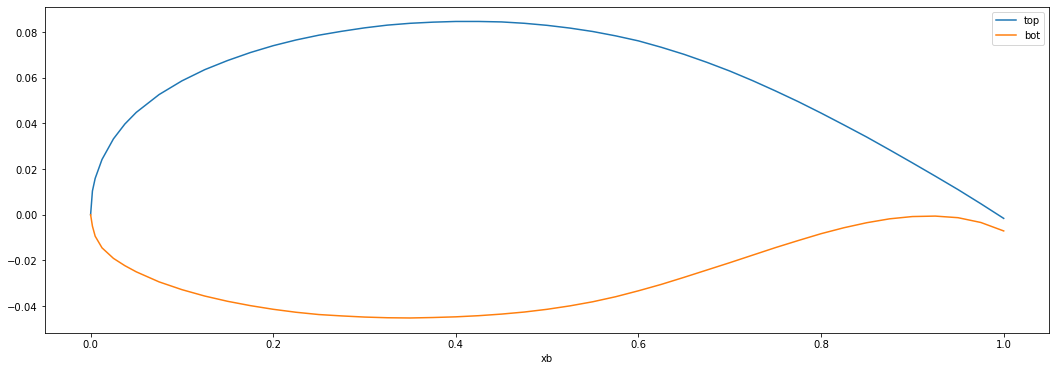

In [5]:
df = pd.read_csv('aerofoil.csv', index_col='xb')
df.plot(figsize=(18, 6))

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
poly = PolynomialFeatures(degree=len(df))
lin.fit(poly.fit_transform(df.index.to_numpy().reshape(-1, 1)), df[['top', 'bot']].values)
df[['ptop', 'pbot']] = lin.predict(poly.transform(df.index.to_numpy().reshape(-1, 1)))

<AxesSubplot:xlabel='xb'>

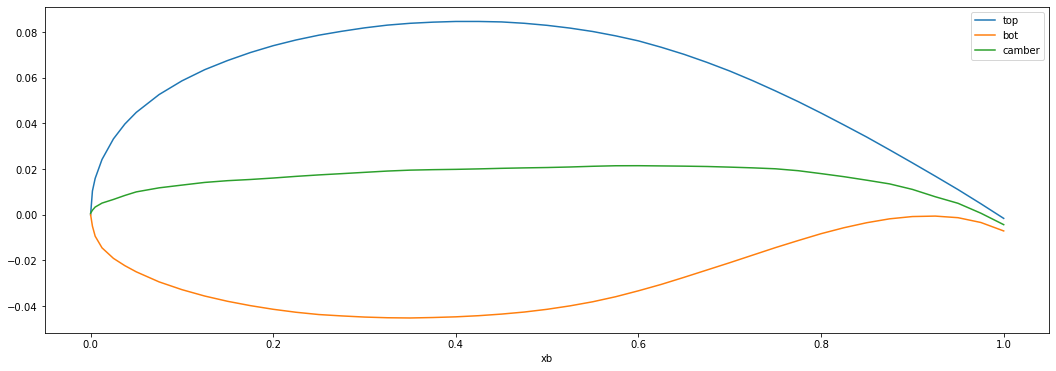

In [56]:
from MathFunctions.Polynomial import Polynomial
top = Polynomial([lin.intercept_[0] + lin.coef_[0][0]] + list(lin.coef_[0][1:]), symbol='\\left(\\frac{x}{c}\\right)')
bot = Polynomial([lin.intercept_[1] + lin.coef_[1][0]] + list(lin.coef_[1][1:]), symbol='\\left(\\frac{x}{c}\\right)')
camber = (top + bot) / 2
df['camber'] = camber(df.index.to_numpy())
df.plot(figsize=(18, 6), y=['top', 'bot', 'camber'])

In [35]:
sum([top(1), bot(1)])/2,  camber(1)

(-0.004353523254394531, -0.004351973533630371)